<a href="https://colab.research.google.com/github/JaswanthJavangula/ML_Practise/blob/main/1ML%20JAshu/RandomForest%5BCLASS%26REGRE%5D/prac_RFC_1.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [3]:
# Install dependencies as needed:
# pip install kagglehub[pandas-datasets]
import kagglehub
from kagglehub import KaggleDatasetAdapter

# Set the path to the file you'd like to load
file_path = "WA_Fn-UseC_-Telco-Customer-Churn.csv"

# Load the latest version
df = kagglehub.load_dataset(
  KaggleDatasetAdapter.PANDAS,
  "blastchar/telco-customer-churn",
  file_path,
  # Provide any additional arguments like
  # sql_query or pandas_kwargs. See the
  # documenation for more information:
  # https://github.com/Kaggle/kagglehub/blob/main/README.md#kaggledatasetadapterpandas
)

print("First 5 records:", df.head())

/tmp/ipykernel_1066/2669226731.py:10: DeprecationWarning: Use dataset_load() instead of load_dataset(). load_dataset() will be removed in a future version.
  df = kagglehub.load_dataset(


Using Colab cache for faster access to the 'telco-customer-churn' dataset.
First 5 records:    customerID  gender  SeniorCitizen Partner Dependents  tenure PhoneService  \
0  7590-VHVEG  Female              0     Yes         No       1           No   
1  5575-GNVDE    Male              0      No         No      34          Yes   
2  3668-QPYBK    Male              0      No         No       2          Yes   
3  7795-CFOCW    Male              0      No         No      45           No   
4  9237-HQITU  Female              0      No         No       2          Yes   

      MultipleLines InternetService OnlineSecurity  ... DeviceProtection  \
0  No phone service             DSL             No  ...               No   
1                No             DSL            Yes  ...              Yes   
2                No             DSL            Yes  ...               No   
3  No phone service             DSL            Yes  ...              Yes   
4                No     Fiber optic            

In [4]:
from sklearn.model_selection import train_test_split
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [5]:
df = pd.DataFrame(df)
df.head(4)

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No


In [6]:
df.columns.isnull()

array([False, False, False, False, False, False, False, False, False,
       False, False, False, False, False, False, False, False, False,
       False, False, False])

In [7]:
df.isnull().sum()

,0
customerID,0
gender,0
SeniorCitizen,0
Partner,0
Dependents,0
tenure,0
PhoneService,0
MultipleLines,0
InternetService,0
OnlineSecurity,0


In [8]:
df.drop('customerID', axis=1, inplace=True)

In [9]:
df["tenure"].value_counts()

,count
tenure,
1,613
72,362
2,238
3,200
4,176
...,...
28,57
39,56
44,51


In [10]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 20 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   gender            7043 non-null   object 
 1   SeniorCitizen     7043 non-null   int64  
 2   Partner           7043 non-null   object 
 3   Dependents        7043 non-null   object 
 4   tenure            7043 non-null   int64  
 5   PhoneService      7043 non-null   object 
 6   MultipleLines     7043 non-null   object 
 7   InternetService   7043 non-null   object 
 8   OnlineSecurity    7043 non-null   object 
 9   OnlineBackup      7043 non-null   object 
 10  DeviceProtection  7043 non-null   object 
 11  TechSupport       7043 non-null   object 
 12  StreamingTV       7043 non-null   object 
 13  StreamingMovies   7043 non-null   object 
 14  Contract          7043 non-null   object 
 15  PaperlessBilling  7043 non-null   object 
 16  PaymentMethod     7043 non-null   object 


In [11]:
df["TotalCharges"]= df["TotalCharges"].replace(" ",np.nan)
df["TotalCharges"] = df["TotalCharges"].astype(np.float64)

In [12]:
y = df["Churn"].map({"Yes": 1 , "No" : 0})
X = df.drop(columns=["Churn"])

In [13]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42,stratify=y)

In [14]:
from sklearn.preprocessing import OneHotEncoder
from sklearn.preprocessing import StandardScaler
from sklearn.compose import ColumnTransformer

num_features = X.select_dtypes(exclude= "object").columns
cat_features = X.select_dtypes(include= "object").columns

preprocessor = ColumnTransformer(
[
    ("One Hot", OneHotEncoder(handle_unknown='ignore'),cat_features),
    ("Standard Scaler", StandardScaler(), num_features),
],remainder="passthrough")



In [15]:

X_train = pd.DataFrame(X_train).fillna(0)


In [16]:
X_test= pd.DataFrame(X_test).fillna(0)

In [17]:
X_train= preprocessor.fit_transform(X_train)
X_test = preprocessor.transform(X_test)

In [18]:
num_features

Index(['SeniorCitizen', 'tenure', 'MonthlyCharges', 'TotalCharges'], dtype='object')

In [19]:
cat_features

Index(['gender', 'Partner', 'Dependents', 'PhoneService', 'MultipleLines',
       'InternetService', 'OnlineSecurity', 'OnlineBackup', 'DeviceProtection',
       'TechSupport', 'StreamingTV', 'StreamingMovies', 'Contract',
       'PaperlessBilling', 'PaymentMethod'],
      dtype='object')

In [20]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score, f1_score, roc_auc_score,roc_curve,recall_score,precision_score,confusion_matrix

In [21]:
def eval_metrics(true,pred):
  acc = accuracy_score(true,pred)
  f1 = f1_score(true,pred)
  roc = roc_auc_score(true,pred)
  rec = recall_score(true,pred)
  pre = precision_score(true,pred)
  return acc,f1,roc,rec,pre


In [22]:

models = {
    "Random Forest": RandomForestClassifier(max_depth=4,min_samples_leaf=3,n_estimators=5,class_weight="balanced"),
    "Logistic Regression": LogisticRegression(),
    "Decision Tree": DecisionTreeClassifier()
}

for model in range(len(list(models))):
  val = list(models.values())[model]
  val.fit(X_train, y_train)

  y_pred_train = val.predict(X_train)
  y_pred_test = val.predict(X_test)

  train_acc ,train_f1,train_roc,train_rec,train_pre = eval_metrics(y_train,y_pred_train)
  test_acc ,test_f1,test_roc,test_rec,test_pre = eval_metrics(y_test,y_pred_test)

  print({f"{list(models.keys())[model]}"})
  print(f"-----model for training set------")
  print(f"Train Acc: {train_acc}")
  print(f"Train F1: {train_f1}")
  print(f"Train Roc: {train_roc}")
  print(f"Train Rec: {train_rec}")
  print(f"Train Pre: {train_pre}")
  print("-"*20)
  print(f"-----model for testing set------")
  print(f"Test Acc: {test_acc}")
  print(f"Test F1: {test_f1}")
  print(f"Test Roc: {test_roc}")
  print(f"Test Rec: {test_rec}")
  print(f"Test Pre: {test_pre}")
  print("-"*20)
  print("\n")

{'Random Forest'}
-----model for training set------
Train Acc: 0.736599219027334
Train F1: 0.6183127572016461
Train Roc: 0.7581313567573639
Train Rec: 0.8040133779264214
Train Pre: 0.5022983702465524
--------------------
-----model for testing set------
Test Acc: 0.7267565649396736
Test F1: 0.6035015447991761
Test Roc: 0.7448513265648815
Test Rec: 0.7834224598930482
Test Pre: 0.490787269681742
--------------------


{'Logistic Regression'}
-----model for training set------
Train Acc: 0.8056443024494143
Train F1: 0.6002190580503833
Train Roc: 0.723937890738315
Train Rec: 0.5498327759197325
Train Pre: 0.6607717041800643
--------------------
-----model for testing set------
Test Acc: 0.8055358410220014
Test F1: 0.6040462427745664
Test Roc: 0.7267547598749645
Test Rec: 0.5588235294117647
Test Pre: 0.6572327044025157
--------------------


{'Decision Tree'}
-----model for training set------
Train Acc: 0.9980475683351083
Train F1: 0.996309963099631
Train Roc: 0.9965347162685314
Train Rec: 0.

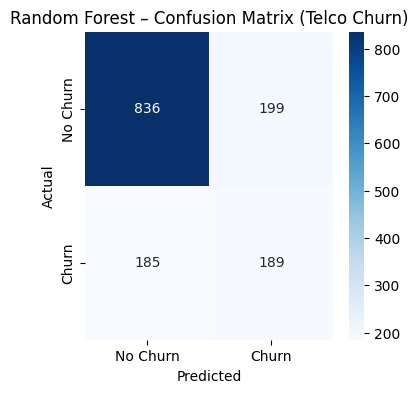

In [23]:
from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

# assume rf_clf is your chosen RF model and you already have y_test_pred
cm = confusion_matrix(y_test, y_pred_test)

plt.figure(figsize=(4, 4))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
            xticklabels=["No Churn", "Churn"],
            yticklabels=["No Churn", "Churn"])
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Random Forest – Confusion Matrix (Telco Churn)")
plt.show()

In [24]:
rf_clf = RandomForestClassifier(
    max_depth=4,min_samples_leaf=3,n_estimators=5,class_weight="balanced")
rf_clf.fit(X_train, y_train)

RandomForestClassifier(class_weight='balanced', max_depth=4, min_samples_leaf=3,
                       n_estimators=5)

In [25]:
506


506

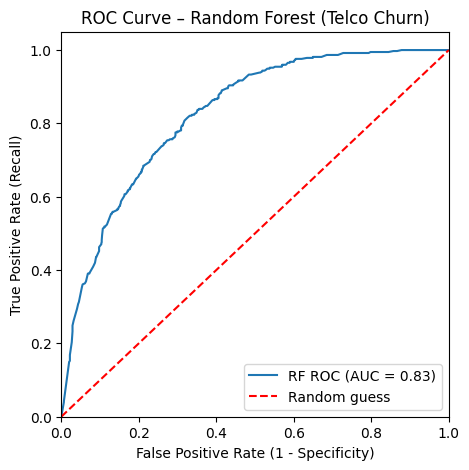

In [26]:
from sklearn.metrics import roc_curve, roc_auc_score
import matplotlib.pyplot as plt

# predicted probabilities for class 1 (churn)
y_test_proba = rf_clf.predict_proba(X_test)[:, 1]

fpr, tpr, thresholds = roc_curve(y_test, y_test_proba)
auc = roc_auc_score(y_test, y_test_proba)

plt.figure(figsize=(5, 5))
plt.plot(fpr, tpr, label=f"RF ROC (AUC = {auc:.2f})")
plt.plot([0, 1], [0, 1], "r--", label="Random guess")
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel("False Positive Rate (1 - Specificity)")
plt.ylabel("True Positive Rate (Recall)")
plt.title("ROC Curve – Random Forest (Telco Churn)")
plt.legend(loc="lower right")
plt.show()

In [29]:
risk_df = pd.DataFrame({
    "y_true" : y_test,
    "y_pred_test" : y_pred_test,
    "y_test_proba" : y_test_proba
})
risk_df = risk_df.reset_index(drop=True)
risk_df.head(4)

,y_true,y_pred_test,y_test_proba
0,0,0,0.295644
1,0,1,0.651937
2,0,0,0.285434
3,0,1,0.477835


In [31]:
risk_df_sorted = risk_df.sort_values(by= "y_test_proba",ascending=False)
risk_df_sorted.head(11)

,y_true,y_pred_test,y_test_proba
344,1,1,0.804655
1355,0,1,0.804655
958,1,0,0.804655
1048,0,1,0.804655
454,0,1,0.804655
1175,1,1,0.804655
889,0,1,0.804655
618,1,1,0.804655
1109,1,1,0.804655
417,1,1,0.804655
